# Importy i stałe

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from tqdm.notebook import tqdm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używam urządzenia: {device}")

PROJECT_DIR = '/content/drive/Shareddrives/adv_images/adversarial_images/'
LABELS_CLEAN_RESNET = PROJECT_DIR + 'prediction_results/clean_ResNet.json'

FEATURE_EXTRACTION_RESULTS = PROJECT_DIR + "feature_extraction/"

Używam urządzenia: cuda


# Definicje klas
- AdversarialImageDataset
- AttackMetadata
- ImageInfo
- InceptionModule
- InceptionCIFAR

In [ ]:
from torch.utils.data import Dataset
import concurrent.futures

class AdversarialImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, preload=False, num_workers=16):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        self.preloaded_images = []

        if os.path.exists(root_dir):
            self.image_files = [f for f in os.listdir(root_dir) if f.endswith(".png")]

        # Sortowanie po indeksie z nazwy (adv_image_0_label_3.png -> 0)
        try:
            self.image_files.sort(key=lambda x: int(x.split('_')[2]))
        except Exception as e:
            print("Błąd sortowania. Sprawdź nazwy plików.")

        if preload:
            print(f"Preloading images from {root_dir} using {num_workers} workers...")

            def load_single_image(file_name):
                path = os.path.join(self.root_dir, file_name)
                try:
                    image = Image.open(path).convert("RGB")
                    if self.transform:
                        image = self.transform(image)
                    return image
                except Exception as e:
                    print(f"Error loading {file_name}: {e}")
                    return None

            # ThreadPoolExecutor do równoległego ładowania (IO-bound)
            with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
                # map zachowuje kolejność zgodną z self.image_files
                results = list(tqdm(executor.map(load_single_image, self.image_files),
                                    total=len(self.image_files),
                                    desc=f"Loading {os.path.basename(root_dir)}"))

            self.preloaded_images = results
            print(f"Finished preloading {len(self.preloaded_images)} images from {root_dir}.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        if self.preloaded_images:
            return self.preloaded_images[idx], self.image_files[idx]
        else:
            path = os.path.join(self.root_dir, self.image_files[idx])
            image = Image.open(path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, self.image_files[idx]

In [4]:
class AttackMetadata:
    def __init__(self, attack_name: str, generated_by: str, model_attacked: str):
        self.attack_name = attack_name
        self.generated_by = generated_by
        self.model_attacked = model_attacked

    def to_dict(self) -> dict:
        return {"attack_name": self.attack_name, "generated_by": self.generated_by, "model_attacked": self.model_attacked}

In [5]:
class ImageInfo:
    def __init__(
        self,
        attack_metadata: AttackMetadata,
        image_index: int,
        true_label: int,
        clean_prediction_label: int,
        adversarial_prediction_label: int,
        clean_feature_map=None,
        adversarial_feature_map=None
    ):
        self.image_index = image_index
        self.true_label = true_label

        self.clean_prediction_label = clean_prediction_label
        self.adversarial_prediction_label = adversarial_prediction_label

        self.clean_feature_map = clean_feature_map
        self.adversarial_feature_map = adversarial_feature_map

        self.attack_metadata = attack_metadata

    def is_clean_prediction_correct(self) -> bool:
        return self.clean_prediction_label == self.true_label

    def is_adversarial_prediction_correct(self) -> bool:
        return self.adversarial_prediction_label == self.true_label

    def was_attack_successful(self) -> bool:
        return (self.clean_prediction_label == self.true_label and self.adversarial_prediction_label != self.true_label)

    def __repr__(self) -> str:
        return (
            f"ImageInfo("
            f"image_index={self.image_index}, "
            f"true_label={self.true_label}, "
            f"clean_prediction_label={self.clean_prediction_label}, "
            f"adversarial_prediction_label={self.adversarial_prediction_label}, "
            f"attack_name={self.attack_metadata.attack_name}, "
            f"clean_feature_map_set={self.clean_feature_map is not None}, "
            f"adversarial_feature_map_set={self.adversarial_feature_map is not None}"
            f")"
        )

    def to_dict(self) -> dict:
        data = {
            "image_index": self.image_index,
            "true_label": self.true_label,

            "clean_prediction_label": self.clean_prediction_label,
            "adversarial_prediction_label": self.adversarial_prediction_label,

            "is_clean_prediction_correct": self.is_clean_prediction_correct(),
            "is_adversarial_prediction_correct": self.is_adversarial_prediction_correct(),
            "was_attack_successful": self.was_attack_successful(),
            "attack_metadata": self.attack_metadata.to_dict()
        }
        # data.update(self.get_feature_map_shapes())
        return data


In [6]:
class Bottleneck(nn.Module):
    def __init__(self, in_planes, growth_rate, drop_rate=0.0):
        super(Bottleneck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, 4*growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4*growth_rate)
        self.conv2 = nn.Conv2d(4*growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
        self.drop_rate = drop_rate

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        if self.drop_rate > 0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        out = torch.cat([out, x], 1)
        return out

class Transition(nn.Module):
    def __init__(self, in_planes, out_planes):
        super(Transition, self).__init__()
        self.bn = nn.BatchNorm2d(in_planes)
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=1, bias=False)

    def forward(self, x):
        out = self.conv(F.relu(self.bn(x)))
        out = F.avg_pool2d(out, 2)
        return out

class DenseNet(nn.Module):
    def __init__(self, block, nblocks, growth_rate=32, reduction=0.5, num_classes=10, drop_rate=0.0):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate
        self.drop_rate = drop_rate

        num_planes = 2 * growth_rate
        self.conv1 = nn.Conv2d(3, num_planes, kernel_size=3, padding=1, bias=False)

        self.layers = nn.ModuleList()
        for i, num_layers in enumerate(nblocks):
            block_layer = self._make_dense_layers(block, num_planes, num_layers)
            self.layers.append(block_layer)
            num_planes += num_layers * growth_rate

            if i != len(nblocks) - 1:
                out_planes = int(math.floor(num_planes * reduction))
                trans_layer = Transition(num_planes, out_planes)
                self.layers.append(trans_layer)
                num_planes = out_planes

        self.bn = nn.BatchNorm2d(num_planes)
        self.linear = nn.Linear(num_planes, num_classes)

    def _make_dense_layers(self, block, in_planes, nblock):
        layers = []
        for i in range(nblock):
            layers.append(block(in_planes, self.growth_rate, drop_rate=self.drop_rate))
            in_planes += self.growth_rate
        return nn.Sequential(*layers)

    def forward_features(self, x):
        out = self.conv1(x)
        for layer in self.layers:
            out = layer(out)

        out = F.relu(self.bn(out))
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(out.size(0), -1)
        return out

    def forward(self, x):
        out = self.forward_features(x)
        out = self.linear(out)
        return out

def densenet121_cifar(drop_rate=0.0):
    return DenseNet(Bottleneck, [6, 12, 24, 16], growth_rate=32, drop_rate=drop_rate)

# Przygotowanie informacji o obrazach
dla ataków wygenerowanych na VGG (One Pixel, PGD, FGSM, Deep Fool, CW, Auto Attack)

In [7]:
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.2435, 0.2616]
BATCH_SIZE = 128

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

clean_dataset = CIFAR10(root='./data', train=False, download=True, transform=preprocess)
clean_loader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Dane gotowe. Clean: {len(clean_dataset)}")

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


Dane gotowe. Clean: 10000


In [8]:
# model for attack genration | attack name | model being attacked:

# VGG | OnePixel | ResNet
LABELS_VGG_ONEPIXEL_RESNET = PROJECT_DIR + 'prediction_results/VGG_OnePixel_ResNet.json'
IMAGES_VGG_ONEPIXEL_RESNET_DIR = PROJECT_DIR + 'test_VGG_OnePixel'

# NAMING: adv_{model_attack_genration}_{attack_name}_{model_being_attacked}_{object_name}
print(IMAGES_VGG_ONEPIXEL_RESNET_DIR)
adv_vgg_onepixel_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_ONEPIXEL_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_onepixel_resnet_loader = DataLoader(adv_vgg_onepixel_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# VGG | PGD | ResNet
LABELS_VGG_PGD_RESNET = PROJECT_DIR + 'prediction_results/VGG_PGD_ResNet.json'
IMAGES_VGG_PGD_RESNET_DIR = PROJECT_DIR + 'test_VGG_PGD'

print(IMAGES_VGG_PGD_RESNET_DIR)
adv_vgg_pgd_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_PGD_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_pgd_resnet_loader = DataLoader(adv_vgg_pgd_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# VGG | FGSM | ResNet
LABELS_VGG_FGSM_RESNET = PROJECT_DIR + 'prediction_results/VGG_FGSM_ResNet.json'
IMAGES_VGG_FGSM_RESNET_DIR = PROJECT_DIR + 'test_VGG_FGSM'

print(IMAGES_VGG_FGSM_RESNET_DIR)
adv_vgg_fgsm_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_FGSM_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_fgsm_resnet_loader = DataLoader(adv_vgg_fgsm_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# VGG | DeepFool | ResNet
LABELS_VGG_DEEPFOOL_RESNET = PROJECT_DIR + 'prediction_results/VGG_DeepFool_ResNet.json'
IMAGES_VGG_DEEPFOOL_RESNET_DIR = PROJECT_DIR + 'test_VGG_DeepFool'

print(IMAGES_VGG_DEEPFOOL_RESNET_DIR)
adv_vgg_deepfool_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_DEEPFOOL_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_deepfool_resnet_loader = DataLoader(adv_vgg_deepfool_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# VGG | CW | ResNet
LABELS_VGG_CW_RESNET = PROJECT_DIR + 'prediction_results/VGG_CW_ResNet.json'
IMAGES_VGG_CW_RESNET_DIR = PROJECT_DIR + 'test_VGG_CW'

print(IMAGES_VGG_CW_RESNET_DIR)
adv_vgg_cw_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_CW_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_cw_resnet_loader = DataLoader(adv_vgg_cw_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# VGG | AutoAttack | ResNet
LABELS_VGG_AUTOATTACK_RESNET = PROJECT_DIR + 'prediction_results/VGG_AutoAttack_ResNet.json'
IMAGES_VGG_AUTOATTACK_RESNET_DIR = PROJECT_DIR + 'test_VGG_AutoAttack'

print(IMAGES_VGG_AUTOATTACK_RESNET_DIR)
adv_vgg_autoattack_resnet_dataset = AdversarialImageDataset(root_dir=IMAGES_VGG_AUTOATTACK_RESNET_DIR, transform=preprocess, preload=True)
adv_vgg_autoattack_resnet_loader = DataLoader(adv_vgg_autoattack_resnet_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

/content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_OnePixel
Preloading images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_OnePixel using 16 workers...


Loading test_VGG_OnePixel:   0%|          | 0/10000 [00:00<?, ?it/s]

Finished preloading 10000 images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_OnePixel.
/content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_PGD
Preloading images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_PGD using 16 workers...


Loading test_VGG_PGD:   0%|          | 0/10000 [00:00<?, ?it/s]

Finished preloading 10000 images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_PGD.
/content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_FGSM
Preloading images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_FGSM using 16 workers...


...

Finished preloading 10000 images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_DeepFool.
/content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_CW
Preloading images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_CW using 16 workers...


Loading test_VGG_CW:   0%|          | 0/10000 [00:00<?, ?it/s]

Finished preloading 10000 images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_CW.
/content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_AutoAttack
Preloading images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_AutoAttack using 16 workers...


Loading test_VGG_AutoAttack:   0%|          | 0/10000 [00:00<?, ?it/s]

Finished preloading 10000 images from /content/drive/Shareddrives/adv_images/adversarial_images/test_VGG_AutoAttack.


In [9]:
len(adv_vgg_autoattack_resnet_dataset)

10000

In [10]:
with open(LABELS_CLEAN_RESNET, 'r') as f:
    labels_clean_resnet = json.load(f)
    labels_clean_resnet = labels_clean_resnet['clean_ResNet']

with open(LABELS_VGG_ONEPIXEL_RESNET, 'r') as f:
    labels_vgg_onepixel_resnet = json.load(f)
    labels_vgg_onepixel_resnet = labels_vgg_onepixel_resnet['VGG_OnePixel_ResNet']

with open(LABELS_VGG_PGD_RESNET, 'r') as f:
    labels_vgg_pgd_resnet = json.load(f)
    labels_vgg_pgd_resnet = labels_vgg_pgd_resnet['VGG_PGD_ResNet']

with open(LABELS_VGG_FGSM_RESNET, 'r') as f:
    labels_vgg_fgsm_resnet = json.load(f)
    labels_vgg_fgsm_resnet = labels_vgg_fgsm_resnet['VGG_FGSM_ResNet']

with open(LABELS_VGG_DEEPFOOL_RESNET, 'r') as f:
    labels_vgg_deepfool_resnet = json.load(f)
    labels_vgg_deepfool_resnet = labels_vgg_deepfool_resnet['VGG_DeepFool_ResNet']

with open(LABELS_VGG_CW_RESNET, 'r') as f:
    labels_vgg_cw_resnet = json.load(f)
    labels_vgg_cw_resnet = labels_vgg_cw_resnet['VGG_CW_ResNet']

with open(LABELS_VGG_AUTOATTACK_RESNET, 'r') as f:
    labels_vgg_autoattack_resnet = json.load(f)
    labels_vgg_autoattack_resnet = labels_vgg_autoattack_resnet['VGG_AutoAttack_ResNet']

metadata_vgg_onepixel_resnet = AttackMetadata("OnePixel", "VGG", "ResNet")
metadata_vgg_pgd_resnet = AttackMetadata("PGD", "VGG", "ResNet")
metadata_vgg_fgsm_resnet = AttackMetadata("FGSM", "VGG", "ResNet")
metadata_vgg_deepfool_resnet = AttackMetadata("DeepFool", "VGG", "ResNet")
metadata_vgg_cw_resnet = AttackMetadata("CW", "VGG", "ResNet")
metadata_vgg_autoattack_resnet = AttackMetadata("AutoAttack", "VGG", "ResNet")

In [11]:
imageinfos_vgg_onepixel_resnet = []
imageinfos_vgg_pgd_resnet = []
imageinfos_vgg_fgsm_resnet = []
imageinfos_vgg_deepfool_resnet = []
imageinfos_vgg_cw_resnet = []
imageinfos_vgg_autoattack_resnet = []

for idx, filename in enumerate(adv_vgg_onepixel_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))

      # attak_metadata, index, label, json clean label, json attack label, (featuremap clean), (featuremap attacked)
      imageinfos_vgg_onepixel_resnet.append(ImageInfo(metadata_vgg_onepixel_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_onepixel_resnet[idx]))

for idx, filename in enumerate(adv_vgg_pgd_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))
      imageinfos_vgg_pgd_resnet.append(ImageInfo(metadata_vgg_pgd_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_pgd_resnet[idx]))

for idx, filename in enumerate(adv_vgg_fgsm_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))

      imageinfos_vgg_fgsm_resnet.append(ImageInfo(metadata_vgg_fgsm_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_fgsm_resnet[idx]))

for idx, filename in enumerate(adv_vgg_deepfool_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))

      imageinfos_vgg_deepfool_resnet.append(ImageInfo(metadata_vgg_deepfool_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_deepfool_resnet[idx]))

for idx, filename in enumerate(adv_vgg_cw_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))

      imageinfos_vgg_cw_resnet.append(ImageInfo(metadata_vgg_cw_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_cw_resnet[idx]))

for idx, filename in enumerate(adv_vgg_autoattack_resnet_dataset.image_files):
      match = re.match(r"adv_image_(\d+)_label_(\d+)\.png", filename)
      image_index, true_label = int(match.group(1)), int(match.group(2))

      imageinfos_vgg_autoattack_resnet.append(ImageInfo(metadata_vgg_autoattack_resnet, image_index, true_label,
                                                        labels_clean_resnet[idx], labels_vgg_autoattack_resnet[idx]))

print(f"Processed {len(imageinfos_vgg_onepixel_resnet)}, {len(imageinfos_vgg_pgd_resnet)} and created ImageInfo objects.")

Processed 10000, 10000 and created ImageInfo objects.


In [12]:
num_examples_to_print = 10
print(f"\nFirst {num_examples_to_print} image prediction infos (calling .to_dict()):")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_onepixel_resnet[i].to_dict())
print(20*"=")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_pgd_resnet[i].to_dict())
print(20*"=")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_fgsm_resnet[i].to_dict())
print(20*"=")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_deepfool_resnet[i].to_dict())
print(20*"=")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_cw_resnet[i].to_dict())
print(20*"=")
for i in range(num_examples_to_print):
    print(imageinfos_vgg_autoattack_resnet[i].to_dict())


First 10 image prediction infos (calling .to_dict()):
{'image_index': 0, 'true_label': 3, 'clean_prediction_label': 3, 'adversarial_prediction_label': 3, 'is_clean_prediction_correct': True, 'is_adversarial_prediction_correct': True, 'was_attack_successful': False, 'attack_metadata': {'attack_name': 'OnePixel', 'generated_by': 'VGG', 'model_attacked': 'ResNet'}}
{'image_index': 1, 'true_label': 8, 'clean_prediction_label': 8, 'adversarial_prediction_label': 8, 'is_clean_prediction_correct': True, 'is_adversarial_prediction_correct': True, 'was_attack_successful': False, 'attack_metadata': {'attack_name': 'OnePixel', 'generated_by': 'VGG', 'model_attacked': 'ResNet'}}
{'image_index': 2, 'true_label': 8, 'clean_prediction_label': 8, 'adversarial_prediction_label': 8, 'is_clean_prediction_correct': True, 'is_adversarial_prediction_correct': True, 'was_attack_successful': False, 'attack_metadata': {'attack_name': 'OnePixel', 'generated_by': 'VGG', 'model_attacked': 'ResNet'}}
{'image_inde

In [13]:
model = densenet121_cifar(drop_rate=0.1)
model.load_state_dict(torch.load("/content/drive/MyDrive/TAI/sem2/DL/densenet_40/260119_DenseNet121_epoch50_dodany_dropout/model_DenseNet121_cifar10_260119.pth", map_location=device))
model.to(device)
model.eval()

DenseNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (layers): ModuleList(
    (0): Sequential(
      (0): Bottleneck(
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (1): Bottleneck(
        (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (2): Bottleneck(
        (bn1): BatchNorm2d(128, eps=1e

In [14]:
CLEAN_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "clean_ResNet"
VGG_ONEPIXEL_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_OnePixel_ResNet"
VGG_PGD_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_PGD_ResNet"
VGG_FGSM_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_FGSM_ResNet"
VGG_DEEPFOOL_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_DeepFool_ResNet"
VGG_CW_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_CW_ResNet"
VGG_AUTOATTACK_RESNET_FM = FEATURE_EXTRACTION_RESULTS + "VGG_AutoAttack_ResNet"

In [ ]:
def extract_clean_features(loader, save_dir):
    global_idx = 0
    clean_features_dict = {}

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Clean Batches"):
            images = images.to(device)
            features = model.forward_features(images)
            features_np = features.cpu().numpy()

            for i in range(features_np.shape[0]):
                # Zapis na dysk
                # np.save(os.path.join(save_dir, f"clean_feature_{global_idx}.npy"), features_np[i])

                # Zapis do słownika w pamięci
                clean_features_dict[global_idx] = features_np[i]

                global_idx += 1

    return clean_features_dict

def extract_adv_features(loader, image_infos, save_dir):
    print(f"--- Przetwarzanie Ataku -> {save_dir} ---")

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    current_idx = 0

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Adv Batches"):
            images = images.to(device)
            features = model.forward_features(images)
            features_np = features.cpu().numpy()

            for i in range(features_np.shape[0]):
                info = image_infos[current_idx]
                original_id = info.image_index

                # np.save(os.path.join(save_dir, f"adv_feature_{original_id}.npy"), features_np[i])
                info.adversarial_feature_map = features_np[i]

                current_idx += 1

# 1. Ekstrakcja czystych cech i przypisanie do obiektów ImageInfo
clean_features = extract_clean_features(clean_loader, CLEAN_RESNET_FM)

# Lista wszystkich list ImageInfo do zaktualizowania
all_image_info_lists = [
    imageinfos_vgg_onepixel_resnet,
    imageinfos_vgg_pgd_resnet,
    imageinfos_vgg_fgsm_resnet,
    imageinfos_vgg_deepfool_resnet,
    imageinfos_vgg_cw_resnet,
    imageinfos_vgg_autoattack_resnet
]

print("Przypisywanie clean_feature_map do obiektów ImageInfo...")
for info_list in all_image_info_lists:
    for info in info_list:
        if info.image_index in clean_features:
            info.clean_feature_map = clean_features[info.image_index]

# 2. Ekstrakcja cech dla pierwszego ataku
extract_adv_features(
    loader=adv_vgg_onepixel_resnet_loader,
    image_infos=imageinfos_vgg_onepixel_resnet,
    save_dir=VGG_ONEPIXEL_RESNET_FM
)

Clean Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Przypisywanie clean_feature_map do obiektów ImageInfo...
--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_OnePixel_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

In [16]:
# pgd
extract_adv_features(
    loader=adv_vgg_pgd_resnet_loader,
    image_infos=imageinfos_vgg_pgd_resnet,
    save_dir=VGG_PGD_RESNET_FM
)
#fgsm
extract_adv_features(
    loader=adv_vgg_fgsm_resnet_loader,
    image_infos=imageinfos_vgg_fgsm_resnet,
    save_dir=VGG_FGSM_RESNET_FM
)
# deep fool
extract_adv_features(
    loader=adv_vgg_deepfool_resnet_loader,
    image_infos=imageinfos_vgg_deepfool_resnet,
    save_dir=VGG_DEEPFOOL_RESNET_FM
)
# cw
extract_adv_features(
    loader=adv_vgg_cw_resnet_loader,
    image_infos=imageinfos_vgg_cw_resnet,
    save_dir=VGG_CW_RESNET_FM
)
# auto attack
extract_adv_features(
    loader=adv_vgg_autoattack_resnet_loader,
    image_infos=imageinfos_vgg_autoattack_resnet,
    save_dir=VGG_AUTOATTACK_RESNET_FM
)

--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_PGD_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_FGSM_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_DeepFool_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_CW_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

--- Przetwarzanie Ataku -> /content/drive/Shareddrives/adv_images/adversarial_images/feature_extraction/VGG_ResNetVGG_AutoAttack_ResNet ---


Adv Batches:   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
def cosine_similarity(a, b):
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return np.dot(a, b) / (norm_a * norm_b)


attacks_data = [
    ("OnePixel", imageinfos_vgg_onepixel_resnet),
    ("PGD", imageinfos_vgg_pgd_resnet),
    ("FGSM", imageinfos_vgg_fgsm_resnet),
    ("DeepFool", imageinfos_vgg_deepfool_resnet),
    ("CW", imageinfos_vgg_cw_resnet),
    ("AutoAttack", imageinfos_vgg_autoattack_resnet)
]

results = []

print("--- Rozpoczynam ponowne obliczanie metryk z podziałem na status ataku ---")

for attack_name, info_list in attacks_data:
    success_count = 0
    fail_count = 0
    skipped_count = 0

    for info in info_list:
        if info.clean_feature_map is None or info.adversarial_feature_map is None:
            continue

        # obrazy poprawnie sklasyfikowane w wersji clean
        if not info.is_clean_prediction_correct():
            skipped_count += 1
            continue

        # klasyfikacja wyniku ataku
        if info.was_attack_successful():
            outcome = "Successful Attack"
            success_count += 1
        else:
            outcome = "Failed Attack"
            fail_count += 1

        clean_fm = info.clean_feature_map
        adv_fm = info.adversarial_feature_map

        l2_dist = np.linalg.norm(clean_fm - adv_fm)
        cos_sim = cosine_similarity(clean_fm, adv_fm)

        results.append({
            "Attack": attack_name,
            "L2 Distance": l2_dist,
            "Cosine Similarity": cos_sim,
            "Outcome": outcome
        })

    print(f"[{attack_name}]\n Przeanalizowano: {success_count + fail_count} (błędny clean: {skipped_count}) | Udane ataki: {success_count} | Nieudane ataki: {fail_count}")

df_results = pd.DataFrame(results)

--- Rozpoczynam ponowne obliczanie metryk z podziałem na status ataku ---
[OnePixel]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 120 | Nieudane ataki: 9175
[PGD]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 7430 | Nieudane ataki: 1865
[FGSM]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 6546 | Nieudane ataki: 2749
[DeepFool]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 44 | Nieudane ataki: 9251
[CW]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 176 | Nieudane ataki: 9119
[AutoAttack]
 Przeanalizowano: 9295 (błędny clean: 705) | Udane ataki: 3095 | Nieudane ataki: 6200


# L2 oraz podobieństwo kosinusowe dla udanych i nieudanych ataków

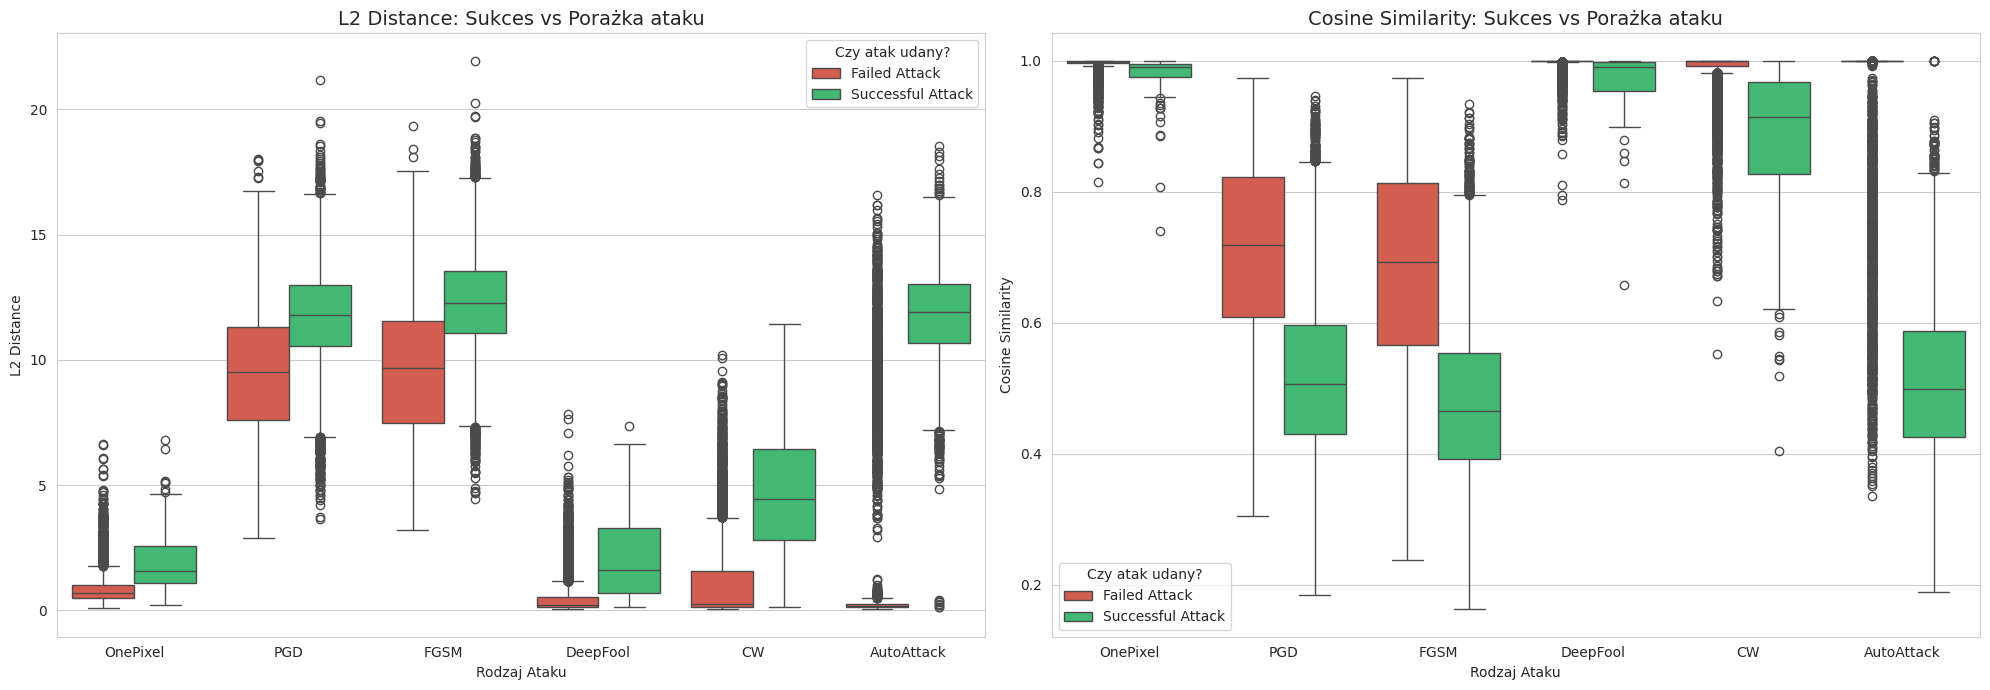

In [18]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Wykres 1: L2 Distance (Udane vs Nieudane)
sns.boxplot(
    data=df_results,
    x='Attack',
    y='L2 Distance',
    hue='Outcome',
    palette={"Successful Attack": "#2ecc71", "Failed Attack": "#e74c3c"},
    ax=axes[0]
)
axes[0].set_title('L2 Distance: Sukces vs Porażka ataku', fontsize=14)
axes[0].set_xlabel('Rodzaj Ataku')
axes[0].set_ylabel('L2 Distance')
axes[0].legend(title='Czy atak udany?')

# Wykres 2: Cosine Similarity (Udane vs Nieudane)
sns.boxplot(
    data=df_results,
    x='Attack',
    y='Cosine Similarity',
    hue='Outcome',
    palette={"Successful Attack": "#2ecc71", "Failed Attack": "#e74c3c"},
    ax=axes[1]
)
axes[1].set_title('Cosine Similarity: Sukces vs Porażka ataku', fontsize=14)
axes[1].set_xlabel('Rodzaj Ataku')
axes[1].set_ylabel('Cosine Similarity')
axes[1].legend(title='Czy atak udany?')

plt.tight_layout()
plt.show()

# L2 oraz podobieństwo kosinusowe dla udanych ataków z podziałem na klasy

In [19]:
CIFAR_CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

results_class_analysis = []

print("Zbieranie danych z podziałem na klasy...")

for attack_name, info_list in attacks_data:
    for info in info_list:
        if info.clean_feature_map is None or info.adversarial_feature_map is None:
            continue

        if not info.is_clean_prediction_correct():
            continue

        clean_fm = info.clean_feature_map
        adv_fm = info.adversarial_feature_map

        l2_dist = np.linalg.norm(clean_fm - adv_fm)
        cos_sim = cosine_similarity(clean_fm, adv_fm)

        results_class_analysis.append({
            "Attack": attack_name,
            "Class Name": CIFAR_CLASSES[info.true_label],
            "L2 Distance": l2_dist,
            "Cosine Similarity": cos_sim,
            "Outcome": "Success" if info.was_attack_successful() else "Fail"
        })

df_class = pd.DataFrame(results_class_analysis)

Zbieranie danych z podziałem na klasy...


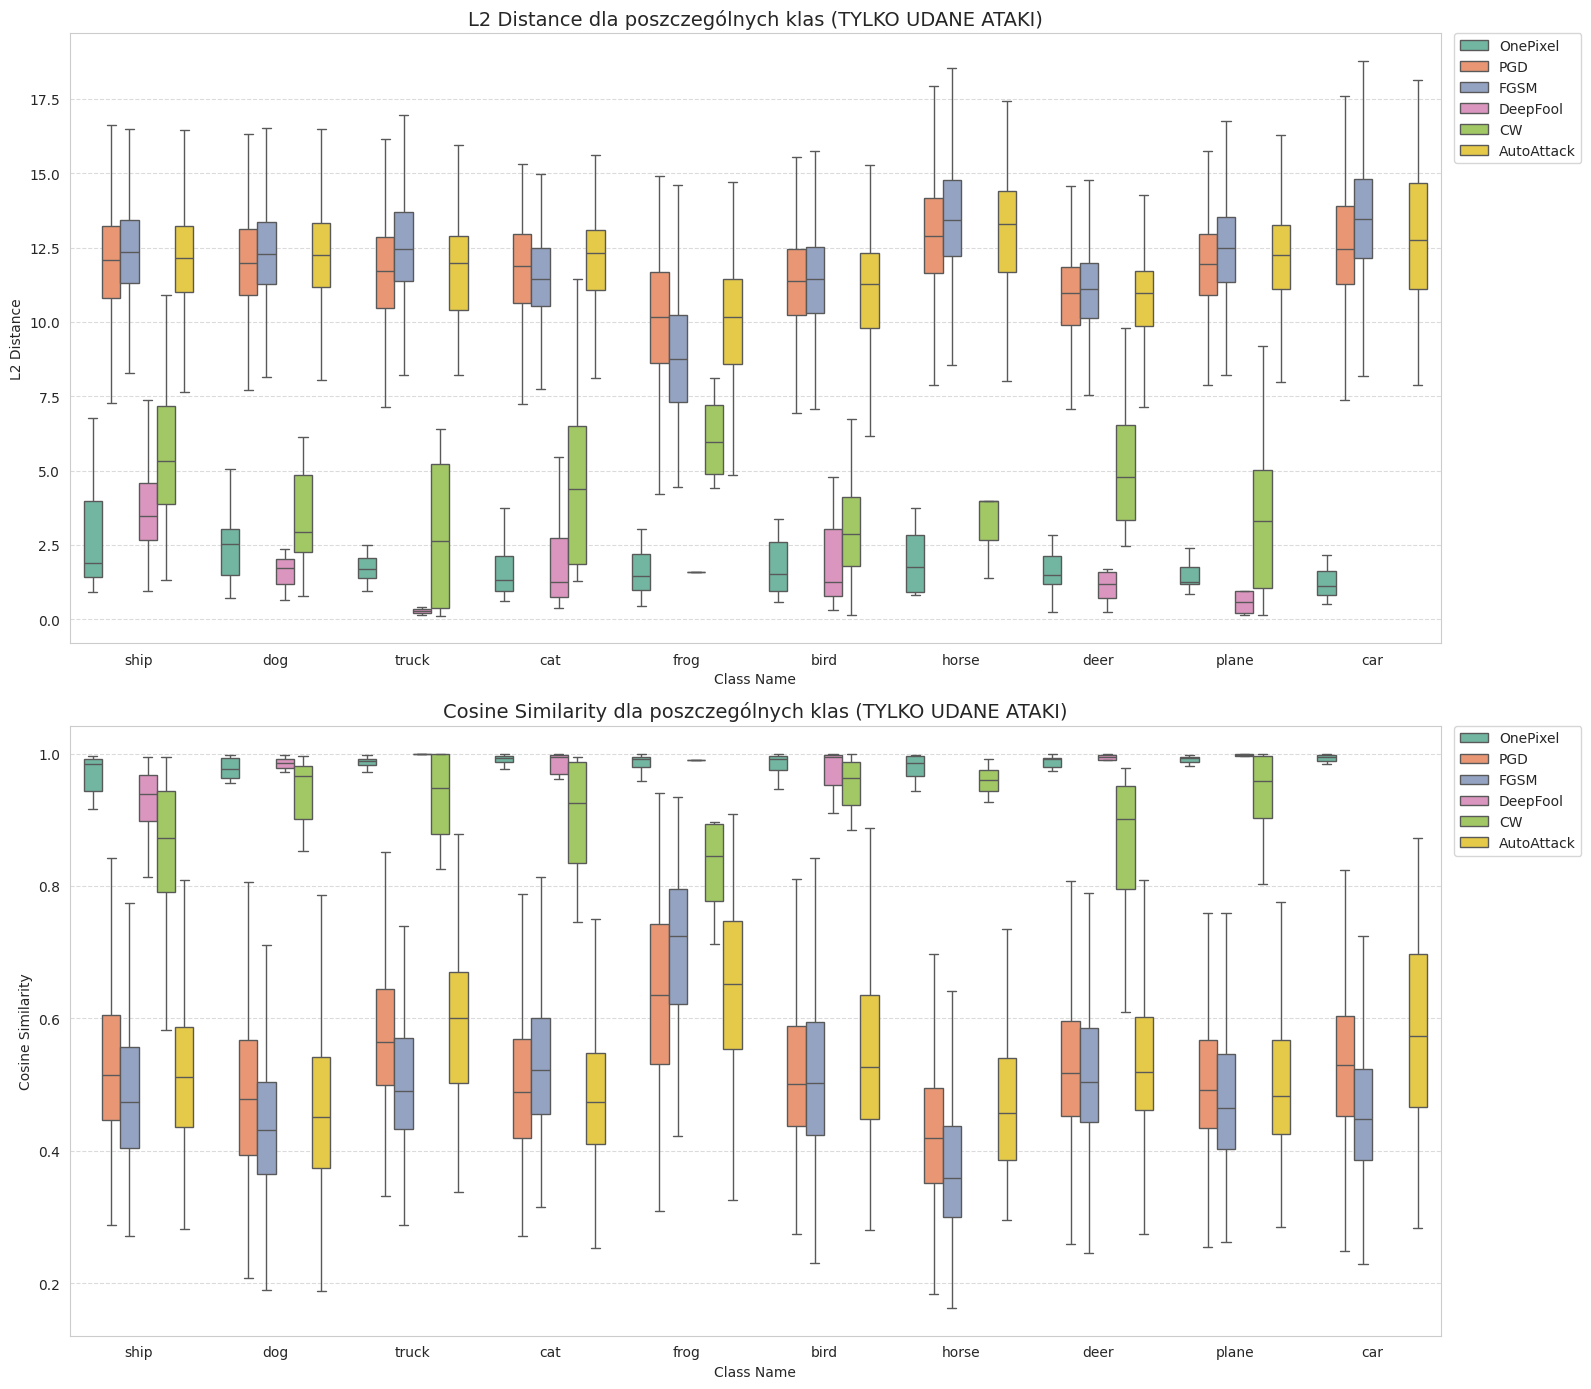

In [20]:
df_class_success = df_class[df_class['Outcome'] == 'Success']

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Wykres 1: L2 Distance per Class (tylko udane ataki)
sns.boxplot(
    data=df_class_success,
    x='Class Name',
    y='L2 Distance',
    hue='Attack',
    ax=axes[0],
    palette="Set2",
    showfliers=False
)
axes[0].set_title('L2 Distance dla poszczególnych klas (TYLKO UDANE ATAKI)', fontsize=14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

# Wykres 2: Cosine Similarity per Class (tylko udane ataki)
sns.boxplot(
    data=df_class_success,
    x='Class Name',
    y='Cosine Similarity',
    hue='Attack',
    ax=axes[1],
    palette="Set2",
    showfliers=False
)
axes[1].set_title('Cosine Similarity dla poszczególnych klas (TYLKO UDANE ATAKI)', fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

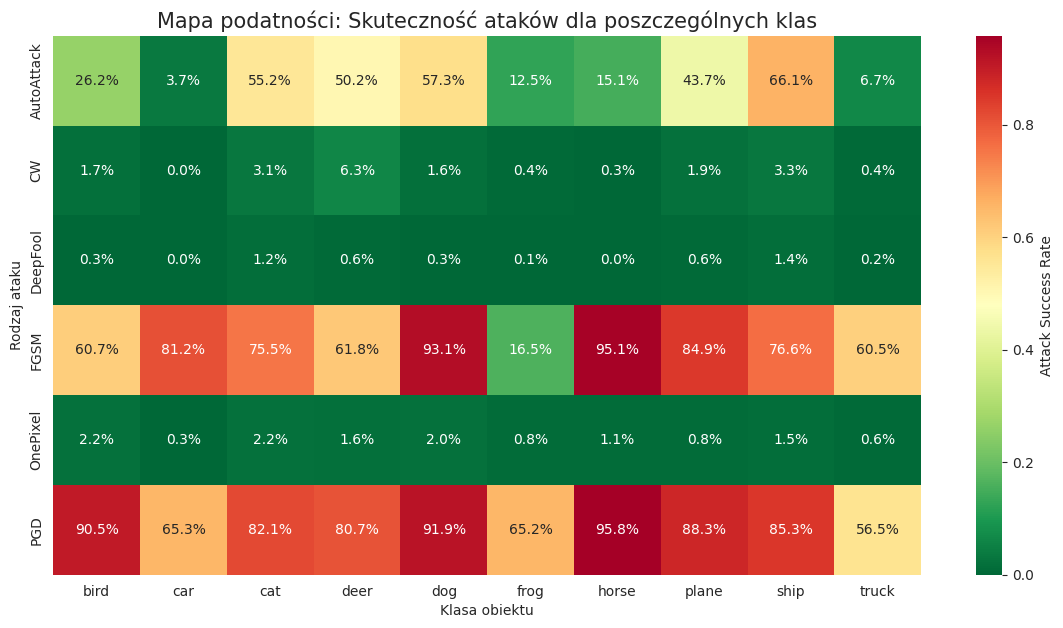

In [21]:
# Obliczanie skuteczności ataków dla każdej klasy (Success Rate)
# Grupujemy po Ataku i Klasie, a następnie liczymy frakcję sukcesów
susceptibility = df_class.groupby(['Attack', 'Class Name'])['Outcome'].apply(lambda x: (x == 'Success').mean()).reset_index(name='Success Rate')

# Heatmapa: Jaki atak na jaką klasę działa najlepiej?
heatmap_data = susceptibility.pivot(index='Attack', columns='Class Name', values='Success Rate')

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn_r', fmt=".1%", cbar_kws={'label': 'Attack Success Rate'})
plt.title('Mapa podatności: Skuteczność ataków dla poszczególnych klas', fontsize=15)
plt.xlabel('Klasa obiektu')
plt.ylabel('Rodzaj ataku')
plt.show()